In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import joblib
from sklearn.preprocessing import label_binarize

In [16]:
df_test = pd.read_csv('test_data')

In [17]:
X_test = df_test.drop(['health_condition'], axis=1)

In [18]:
cat_cols = X_test.select_dtypes(include=['object']).columns
X_test[cat_cols] = X_test[cat_cols].astype('category')

In [19]:
y_test = df_test['health_condition']

In [20]:
df_test.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
0,7.65,75.2,22.98,1881.0,6995.0,50.4,2.33,veg,medium,poor,active,occasional,male,at-risk
1,8.95,74.4,18.57,1940.0,10242.0,32.5,2.29,veg,low,average,active,occasional,male,fit
2,6.86,90.9,23.17,2036.0,5786.0,27.2,2.50,balanced,high,poor,moderate,occasional,other,at-risk
3,6.80,61.2,18.43,2247.0,12669.0,55.3,2.65,balanced,medium,good,moderate,no,male,at-risk
4,8.27,74.7,22.36,2722.0,13482.0,58.0,3.17,veg,high,average,active,occasional,other,at-risk


In [21]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89246 entries, 0 to 89245
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sleep_duration           89246 non-null  float64
 1   heart_rate               89246 non-null  float64
 2   bmi                      89246 non-null  float64
 3   calorie_expenditure      89246 non-null  float64
 4   step_count               89246 non-null  float64
 5   exercise_duration        89246 non-null  float64
 6   water_intake             89246 non-null  float64
 7   diet_type                89246 non-null  object 
 8   stress_level             89246 non-null  object 
 9   sleep_quality            89246 non-null  object 
 10  physical_activity_level  89246 non-null  object 
 11  smoking_alcohol          89246 non-null  object 
 12  gender                   89246 non-null  object 
 13  health_condition         89246 non-null  object 
dtypes: float64(7), object(

In [22]:
model = joblib.load('xgb1.joblib')

In [41]:
raw_scores = model.predict_proba(X_test)

In [23]:
predictions = model.predict(X_test)

In [40]:
print(predictions.shape)

(89246,)


In [24]:
le = joblib.load('label_encoder.joblib')

In [25]:
df_test['predictions'] = le.inverse_transform(predictions)

In [27]:
qck_acc = ((df_test['predictions'] == df_test['health_condition'] ).sum() / len(df_test)) * 100
print(f"correct predictions : {qck_acc:.2f}%")

correct predictions : 90.66%


In [28]:
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, auc)

In [30]:
print("--- Classification Report ---")
print(classification_report(y_test, df_test['predictions']))

--- Classification Report ---
              precision    recall  f1-score   support

     at-risk       0.99      0.90      0.94     76589
         fit       0.59      0.92      0.72      5103
   unhealthy       0.63      0.91      0.74      7554

    accuracy                           0.91     89246
   macro avg       0.74      0.91      0.80     89246
weighted avg       0.93      0.91      0.91     89246



--- Confusion Matrix ---


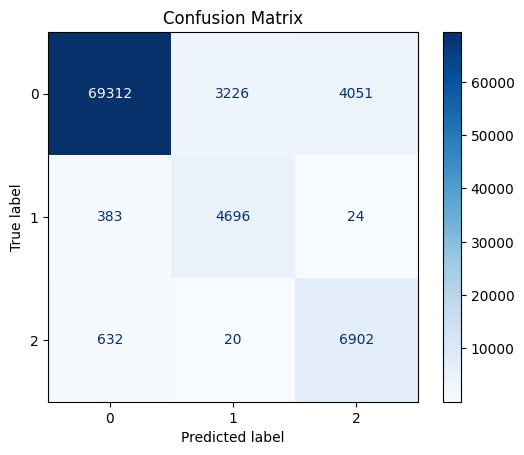

In [32]:
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, df_test['predictions'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [51]:
classes = [0, 1, 2]
y_test_enc = le.transform(y_test)
y_test_binarized = label_binarize(y_test_enc, classes=classes)

In [53]:
print(np.unique(y_test_binarized))
class_names = le.inverse_transform(classes)

[0 1]


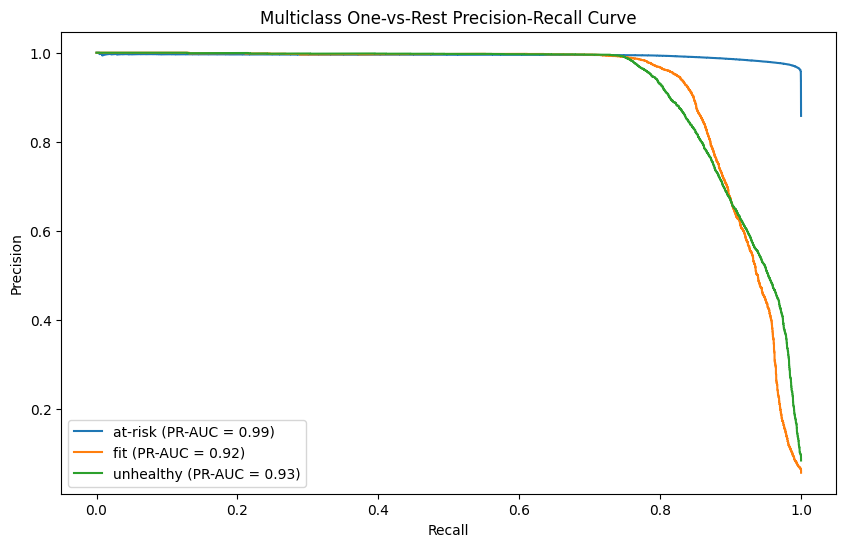

In [54]:
plt.figure(figsize=(10,6))
for i, class_name in enumerate(class_names):
    true_class = y_test_binarized[:, i]
    score_class = raw_scores[:, i]

    precision, recall, _ = precision_recall_curve(true_class, score_class)

    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multiclass One-vs-Rest Precision-Recall Curve')
plt.legend(loc='lower left')